### Importar librerias

In [44]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import hashlib

# Diccionario de hoteles
hotels = {
    "Vitoria": 'https://www.booking.com/reviews/es/hotel/libere-vitoria-centro.es.html?aid=356980&label=gog235jc-1DCA0oRkIVbGliZXJlLXZpdG9yaWEtY2VudHJvSDNYA2hGiAEBmAEKuAEXyAEM2AED6AEBiAIBqAIDuALSzuu6BsACAdICJDBiNGMxOWY2LWVlOGMtNDU3ZS05ZDZlLTVmYzM2NDNjZTM5M9gCBOACAQ&sid=b89a34b9ace8403db8dbb71ddde917f9&customer_type=total&hp_nav=0&keep_landing=1&order=featuredreviews&page=1&r_lang=es&rows=75&',
"Donosti":   'https://www.booking.com/reviews/es/hotel/koisi-hostel.es.html?aid=356980&label=gog235jc-1DCA0oRkIMa29pc2ktaG9zdGVsSDNYA2hGiAEBmAEKuAEXyAEM2AED6AEBiAIBqAIDuAKIzuu6BsACAdICJDBkYmJjNGJmLTBiYzYtNDUzNS1hYjM2LWU5N2RlMTFkZDU2N9gCBOACAQ&sid=b89a34b9ace8403db8dbb71ddde917f9&customer_type=total&hp_nav=0&keep_landing=1&order=featuredreviews&page=1&r_lang=es&rows=75&',
"BilbaoMuseo":  'https://www.booking.com/reviews/es/hotel/apartamentos-libere-bilbao-guggenheim.es.html',
"BilbaoLaVieja":   'https://www.booking.com/reviews/es/hotel/apartamentos-libere-bilbao-la-vieja.es.html',
"ValenciaAbastos":    'https://www.booking.com/reviews/es/hotel/apartamentos-libere-valencia-abastos.es.html',
"PamplonaYamaguchi":    'https://www.booking.com/reviews/es/hotel/apartamentos-libere-pamplona-yamaguchi.es.html',
"ValenciaJardinBotanico":    'https://www.booking.com/reviews/es/hotel/apartamentos-libere-valencia-jardin-botanico.es.html',
"MadridPalacioReal":    'https://www.booking.com/reviews/es/hotel/libere-madrid-palacio-real.es.html',
"MalagaTeatroRomano":    'https://www.booking.com/reviews/es/hotel/apartamentosliberemalagateatroromano.es.html',
"GranadaCatedral":    'https://www.booking.com/reviews/es/hotel/apartamentos-libere-granada-catedral.es.html',
"MalagaLaMerced":    'https://www.booking.com/reviews/es/hotel/libere-malaga-la-merced.es.html',
"CordobaPatio":    'https://www.booking.com/reviews/es/hotel/libere-cordoba-patio-santa-marta.es.html?aid=356980&label=gog235jc-1DCA0oRkIgbGliZXJlLWNvcmRvYmEtcGF0aW8tc2FudGEtbWFydGFIM1gDaEaIAQGYAQq4ARfIAQzYAQPoAQGIAgGoAgO4AruB8LoGwAIB0gIkZWRiMTQzODktYmYyZi00NGJkLTg4MDYtNzBlYjc1YmFiZTM12AIE4AIB&sid=b89a34b9ace8403db8dbb71ddde917f9&customer_type=total&hp_nav=0&keep_landing=1&order=featuredreviews&page=1&r_lang=es&rows=75&'
}

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

all_reviews = []

for hotel_name, base_url in hotels.items():
    print(f"\nProcesando hotel: {hotel_name}")

    page = 1
    seen_reviews = set()

    while True:
        url = f"{base_url}?page={page}"
        r = requests.get(url, headers=headers)
        soup = BeautifulSoup(r.text, "html.parser")

        reviews = soup.select("li.review_item")
        if not reviews:
            print("No hay más reseñas visibles.")
            break

        new_reviews = 0

        for r_elem in reviews:
            # Creamos una huella única de la reseña
            review_text = r_elem.get_text(strip=True)
            review_hash = hashlib.md5(review_text.encode()).hexdigest()

            if review_hash in seen_reviews:
                continue

            seen_reviews.add(review_hash)
            new_reviews += 1

            username = r_elem.select_one(".reviewer_name")
            country = r_elem.select_one(".reviewer_country")
            score = r_elem.select_one(".review-score-badge")
            date_written = r_elem.select_one(".review_item_date")
            positive = r_elem.select_one(".review_pos")
            negative = r_elem.select_one(".review_neg")
            tags_elements = r_elem.select(".review_info_tag")
            tags = [t.get_text(strip=True) for t in tags_elements]

            score_text = score.get_text(strip=True).replace(",", ".") if score else None
            score_val = float(score_text) if score_text else None

            all_reviews.append({
                "hotel": hotel_name,
                "username": username.get_text(strip=True) if username else None,
                "country": country.get_text(strip=True) if country else None,
                "score": score_val,
                "date_written": date_written.get_text(strip=True) if date_written else None,
                "positive": positive.get_text(strip=True) if positive else None,
                "negative": negative.get_text(strip=True) if negative else None,
                "tags": tags
            })

        print(f"Página {page} → nuevas reseñas: {new_reviews}")

        if new_reviews == 0:
            print("No hay reseñas nuevas. Fin del hotel.")
            break

        page += 1
        time.sleep(2)

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("Booking_hotels.csv", index=False, encoding="utf-8-sig")

print(f"\nTOTAL RESEÑAS DESCARGADAS: {len(df)}")



Procesando hotel: Vitoria
Página 1 → nuevas reseñas: 24
Página 2 → nuevas reseñas: 0
No hay reseñas nuevas. Fin del hotel.

Procesando hotel: Donosti
Página 1 → nuevas reseñas: 24
Página 2 → nuevas reseñas: 0
No hay reseñas nuevas. Fin del hotel.

Procesando hotel: BilbaoMuseo
Página 1 → nuevas reseñas: 24
Página 2 → nuevas reseñas: 25
Página 3 → nuevas reseñas: 25
Página 4 → nuevas reseñas: 25
No hay más reseñas visibles.

Procesando hotel: BilbaoLaVieja
Página 1 → nuevas reseñas: 24
Página 2 → nuevas reseñas: 25
Página 3 → nuevas reseñas: 25
Página 4 → nuevas reseñas: 25
Página 5 → nuevas reseñas: 25
Página 6 → nuevas reseñas: 25
No hay más reseñas visibles.

Procesando hotel: ValenciaAbastos
Página 1 → nuevas reseñas: 24
Página 2 → nuevas reseñas: 25
Página 3 → nuevas reseñas: 24
Página 4 → nuevas reseñas: 25
Página 5 → nuevas reseñas: 25
No hay más reseñas visibles.

Procesando hotel: PamplonaYamaguchi
Página 1 → nuevas reseñas: 24
Página 2 → nuevas reseñas: 25
Página 3 → nuevas r

In [ ]:
df=pd.read_csv('Booking_hotels.csv')
df.head

<bound method NDFrame.head of              hotel  username    country  score  \
0          Vitoria   Montero     España    7.0   
1          Vitoria     Gómez     España    7.0   
2          Vitoria  Cristina     España    9.0   
3          Vitoria    Manuel     España   10.0   
4          Vitoria      Jose     España    8.0   
...            ...       ...        ...    ...   
1222  CordobaPatio  Martinez     España    8.0   
1223  CordobaPatio   Dayanne     España   10.0   
1224  CordobaPatio    Eloisa  Argentina    8.0   
1225  CordobaPatio    Walter    Uruguay   10.0   
1226  CordobaPatio  Patricia       Perú    9.0   

                            date_written  \
0     Escrito en 12 de diciembre de 2025   
1     Escrito en 11 de diciembre de 2025   
2     Escrito en 10 de diciembre de 2025   
3      Escrito en 8 de diciembre de 2025   
4      Escrito en 8 de diciembre de 2025   
...                                  ...   
1222    Escrito en 30 de octubre de 2025   
1223    Escrito e

In [ ]:
df.shape

(1227, 8)

ESTO BIEN

VITORIA

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

base_url = "https://www.booking.com/reviews/es/hotel/libere-vitoria-centro.es.html"

all_reviews = []
page = 1

while True:
    url = f"{base_url}?aid=356980&label=gog235jc-1DCA0oRkIVbGliZXJlLXZpdG9yaWEtY2VudHJvSDNYA2hGiAEBmAEKuAEXyAEM2AED6AEBiAIBqAIDuALSzuu6BsACAdICJDBiNGMxOWY2LWVlOGMtNDU3ZS05ZDZlLTVmYzM2NDNjZTM5M9gCBOACAQ&sid=b89a34b9ace8403db8dbb71ddde917f9&customer_type=total&hp_nav=0&keep_landing=1&order=featuredreviews&page={page}&r_lang=es&rows=75&"

    print(f"Descargando página {page} ...")
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    # Seleccionar todas las reseñas
    reviews = soup.select("li.review_item")  # selector para este link funciona
    if not reviews:
        print("No hay más reseñas, finalizando.")
        break

    print(f"Encontradas {len(reviews)} reseñas en la página {page}")

    for r_elem in reviews:
        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        # Convertir puntuación a float
        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("Vitoria_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"TOTAL RESEÑAS DESCARGADAS: {len(df)}")


Descargando página 1 ...
Encontradas 24 reseñas en la página 1
Descargando página 2 ...
Encontradas 25 reseñas en la página 2
Descargando página 3 ...
Encontradas 25 reseñas en la página 3
Descargando página 4 ...
Encontradas 25 reseñas en la página 4
Descargando página 5 ...
Encontradas 25 reseñas en la página 5
Descargando página 6 ...
Encontradas 25 reseñas en la página 6
Descargando página 7 ...
Encontradas 24 reseñas en la página 7
Descargando página 8 ...
Encontradas 25 reseñas en la página 8
Descargando página 9 ...
Encontradas 25 reseñas en la página 9
Descargando página 10 ...
Encontradas 25 reseñas en la página 10
Descargando página 11 ...
Encontradas 25 reseñas en la página 11
Descargando página 12 ...
Encontradas 25 reseñas en la página 12
Descargando página 13 ...
Encontradas 25 reseñas en la página 13
Descargando página 14 ...
Encontradas 25 reseñas en la página 14
Descargando página 15 ...
Encontradas 25 reseñas en la página 15
Descargando página 16 ...
Encontradas 25 re

In [ ]:
import pandas as pd

df = pd.read_csv("Vitoria_booking_reviews_todas.csv", encoding="utf-8-sig")

# Revisar duplicados por usuario + fecha
duplicates = df.duplicated(subset=["username", "date_written"])
print(f"Número de reseñas duplicadas: {duplicates.sum()}")


Número de reseñas duplicadas: 16


DONOSTI

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# Link del hotel Koisi Hostel en Donosti
base_url = "https://www.booking.com/reviews/es/hotel/koisi-hostel.es.html?aid=356980&label=gog235jc-1DCA0oRkIMa29pc2ktaG9zdGVsSDNYA2hGiAEBmAEKuAEXyAEM2AED6AEBiAIBqAIDuAKIzuu6BsACAdICJDBkYmJjNGJmLTBiYzYtNDUzNS1hYjM2LWU5N2RlMTFkZDU2N9gCBOACAQ&sid=b89a34b9ace8403db8dbb71ddde917f9&customer_type=total&hp_nav=0&keep_landing=1&order=featuredreviews&page=1&r_lang=es&rows=75&"

all_reviews = []
page = 1
last_reviews_count = 0  # Para evitar bucles infinitos

while True:
    url = base_url.replace("page=1", f"page={page}")  # Paginación automática
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    # Seleccionar todas las reseñas
    reviews = soup.select("li.review_item")
    current_count = len(reviews)

    if current_count == 0 or current_count == last_reviews_count:
        print("No hay más reseñas o se repite la página, finalizando.")
        break

    print(f"Encontradas {current_count} reseñas en la página {page}")
    last_reviews_count = current_count

    for r_elem in reviews:
        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        # Convertir puntuación a float
        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("Donosti_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"TOTAL RESEÑAS DESCARGADAS: {len(df)}")


Descargando página 1 ...
Encontradas 24 reseñas en la página 1
Descargando página 2 ...
Encontradas 25 reseñas en la página 2
Descargando página 3 ...
No hay más reseñas o se repite la página, finalizando.
TOTAL RESEÑAS DESCARGADAS: 49


BILBAO MUSEO

In [45]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import hashlib

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# URL base del hotel BilbaoMuseo con parámetro rows para obtener más reseñas por página
base_url = "https://www.booking.com/reviews/es/hotel/apartamentos-libere-bilbao-guggenheim.es.html?rows=75"

all_reviews = []
seen_reviews = set()  # Para evitar duplicados
page = 1

while True:
    url = f"{base_url}&page={page}"
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    reviews = soup.select("li.review_item")
    if not reviews:
        print("No hay más reseñas visibles, finalizando.")
        break

    new_reviews = 0

    for r_elem in reviews:
        review_text = r_elem.get_text(strip=True)
        review_hash = hashlib.md5(review_text.encode()).hexdigest()

        if review_hash in seen_reviews:
            continue
        seen_reviews.add(review_hash)
        new_reviews += 1

        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    print(f"Página {page} → nuevas reseñas: {new_reviews}")

    if new_reviews == 0:
        print("No se encontraron reseñas nuevas, fin del hotel.")
        break

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("BilbaoMuseo_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"\nTOTAL RESEÑAS DESCARGADAS: {len(df)}")


Descargando página 1 ...
Página 1 → nuevas reseñas: 24
Descargando página 2 ...
Página 2 → nuevas reseñas: 25
Descargando página 3 ...
Página 3 → nuevas reseñas: 25
Descargando página 4 ...
Página 4 → nuevas reseñas: 25
Descargando página 5 ...
No hay más reseñas visibles, finalizando.

TOTAL RESEÑAS DESCARGADAS: 99


bilbao lavieja

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# Link del hotel Koisi Hostel en Donosti
base_url = "https://www.booking.com/reviews/es/hotel/apartamentos-libere-bilbao-la-vieja.es.html"

all_reviews = []
page = 1
last_reviews_count = 0  # Para evitar bucles infinitos

while True:
    url = base_url.replace("page=1", f"page={page}")  # Paginación automática
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    # Seleccionar todas las reseñas
    reviews = soup.select("li.review_item")
    current_count = len(reviews)

    if current_count == 0 or current_count == last_reviews_count:
        print("No hay más reseñas o se repite la página, finalizando.")
        break

    print(f"Encontradas {current_count} reseñas en la página {page}")
    last_reviews_count = current_count

    for r_elem in reviews:
        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        # Convertir puntuación a float
        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("BilbaolaVieja_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"TOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Encontradas 24 reseñas en la página 1
Descargando página 2 ...
No hay más reseñas o se repite la página, finalizando.
TOTAL RESEÑAS DESCARGADAS: 24


In [46]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import hashlib

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# URL base del hotel BilbaoMuseo con parámetro rows para obtener más reseñas por página
base_url = "https://www.booking.com/reviews/es/hotel/apartamentos-libere-bilbao-la-vieja.es.html?rows=75"

all_reviews = []
seen_reviews = set()  # Para evitar duplicados
page = 1

while True:
    url = f"{base_url}&page={page}"
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    reviews = soup.select("li.review_item")
    if not reviews:
        print("No hay más reseñas visibles, finalizando.")
        break

    new_reviews = 0

    for r_elem in reviews:
        review_text = r_elem.get_text(strip=True)
        review_hash = hashlib.md5(review_text.encode()).hexdigest()

        if review_hash in seen_reviews:
            continue
        seen_reviews.add(review_hash)
        new_reviews += 1

        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    print(f"Página {page} → nuevas reseñas: {new_reviews}")

    if new_reviews == 0:
        print("No se encontraron reseñas nuevas, fin del hotel.")
        break

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("BilbaolaVieja_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"\nTOTAL RESEÑAS DESCARGADAS: {len(df)}")


Descargando página 1 ...
Página 1 → nuevas reseñas: 24
Descargando página 2 ...
Página 2 → nuevas reseñas: 25
Descargando página 3 ...
Página 3 → nuevas reseñas: 25
Descargando página 4 ...
Página 4 → nuevas reseñas: 25
Descargando página 5 ...
Página 5 → nuevas reseñas: 25
Descargando página 6 ...
Página 6 → nuevas reseñas: 25
Descargando página 7 ...
No hay más reseñas visibles, finalizando.

TOTAL RESEÑAS DESCARGADAS: 149


ValenciaAbastos

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# Link del hotel Koisi Hostel en Donosti
base_url = "https://www.booking.com/reviews/es/hotel/apartamentos-libere-valencia-abastos.es.html"

all_reviews = []
page = 1
last_reviews_count = 0  # Para evitar bucles infinitos

while True:
    url = base_url.replace("page=1", f"page={page}")  # Paginación automática
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    # Seleccionar todas las reseñas
    reviews = soup.select("li.review_item")
    current_count = len(reviews)

    if current_count == 0 or current_count == last_reviews_count:
        print("No hay más reseñas o se repite la página, finalizando.")
        break

    print(f"Encontradas {current_count} reseñas en la página {page}")
    last_reviews_count = current_count

    for r_elem in reviews:
        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        # Convertir puntuación a float
        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("ValenciaAbastos_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"TOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Encontradas 24 reseñas en la página 1
Descargando página 2 ...
No hay más reseñas o se repite la página, finalizando.
TOTAL RESEÑAS DESCARGADAS: 24


In [47]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import hashlib

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# URL base del hotel BilbaoMuseo con parámetro rows para obtener más reseñas por página
base_url = "https://www.booking.com/reviews/es/hotel/apartamentos-libere-valencia-abastos.es.html?rows=75"

all_reviews = []
seen_reviews = set()  # Para evitar duplicados
page = 1

while True:
    url = f"{base_url}&page={page}"
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    reviews = soup.select("li.review_item")
    if not reviews:
        print("No hay más reseñas visibles, finalizando.")
        break

    new_reviews = 0

    for r_elem in reviews:
        review_text = r_elem.get_text(strip=True)
        review_hash = hashlib.md5(review_text.encode()).hexdigest()

        if review_hash in seen_reviews:
            continue
        seen_reviews.add(review_hash)
        new_reviews += 1

        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    print(f"Página {page} → nuevas reseñas: {new_reviews}")

    if new_reviews == 0:
        print("No se encontraron reseñas nuevas, fin del hotel.")
        break

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("ValenciaAbastos_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"\nTOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Página 1 → nuevas reseñas: 24
Descargando página 2 ...
Página 2 → nuevas reseñas: 25
Descargando página 3 ...
Página 3 → nuevas reseñas: 24
Descargando página 4 ...
Página 4 → nuevas reseñas: 25
Descargando página 5 ...
Página 5 → nuevas reseñas: 25
Descargando página 6 ...
No hay más reseñas visibles, finalizando.

TOTAL RESEÑAS DESCARGADAS: 123


PamplonaYamaguchi

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# Link del hotel Koisi Hostel en Donosti
base_url = "https://www.booking.com/reviews/es/hotel/apartamentos-libere-pamplona-yamaguchi.es.html"

all_reviews = []
page = 1
last_reviews_count = 0  # Para evitar bucles infinitos

while True:
    url = base_url.replace("page=1", f"page={page}")  # Paginación automática
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    # Seleccionar todas las reseñas
    reviews = soup.select("li.review_item")
    current_count = len(reviews)

    if current_count == 0 or current_count == last_reviews_count:
        print("No hay más reseñas o se repite la página, finalizando.")
        break

    print(f"Encontradas {current_count} reseñas en la página {page}")
    last_reviews_count = current_count

    for r_elem in reviews:
        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        # Convertir puntuación a float
        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("PamplonaYamaguchi_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"TOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Encontradas 24 reseñas en la página 1
Descargando página 2 ...
No hay más reseñas o se repite la página, finalizando.
TOTAL RESEÑAS DESCARGADAS: 24


In [48]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import hashlib

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# URL base del hotel BilbaoMuseo con parámetro rows para obtener más reseñas por página
base_url = "https://www.booking.com/reviews/es/hotel/apartamentos-libere-pamplona-yamaguchi.es.html?rows=75"

all_reviews = []
seen_reviews = set()  # Para evitar duplicados
page = 1

while True:
    url = f"{base_url}&page={page}"
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    reviews = soup.select("li.review_item")
    if not reviews:
        print("No hay más reseñas visibles, finalizando.")
        break

    new_reviews = 0

    for r_elem in reviews:
        review_text = r_elem.get_text(strip=True)
        review_hash = hashlib.md5(review_text.encode()).hexdigest()

        if review_hash in seen_reviews:
            continue
        seen_reviews.add(review_hash)
        new_reviews += 1

        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    print(f"Página {page} → nuevas reseñas: {new_reviews}")

    if new_reviews == 0:
        print("No se encontraron reseñas nuevas, fin del hotel.")
        break

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("PamplonaYamaguchi_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"\nTOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Página 1 → nuevas reseñas: 24
Descargando página 2 ...
Página 2 → nuevas reseñas: 25
Descargando página 3 ...
Página 3 → nuevas reseñas: 25
Descargando página 4 ...
Página 4 → nuevas reseñas: 25
Descargando página 5 ...
Página 5 → nuevas reseñas: 25
Descargando página 6 ...
Página 6 → nuevas reseñas: 25
Descargando página 7 ...
Página 7 → nuevas reseñas: 25
Descargando página 8 ...
Página 8 → nuevas reseñas: 25
Descargando página 9 ...
Página 9 → nuevas reseñas: 25
Descargando página 10 ...
Página 10 → nuevas reseñas: 25
Descargando página 11 ...
Página 11 → nuevas reseñas: 25
Descargando página 12 ...
Página 12 → nuevas reseñas: 25
Descargando página 13 ...
Página 13 → nuevas reseñas: 25
Descargando página 14 ...
No hay más reseñas visibles, finalizando.

TOTAL RESEÑAS DESCARGADAS: 324


ValenciaJardinBotanico

In [ ]:

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# Link del hotel Koisi Hostel en Donosti
base_url = "https://www.booking.com/reviews/es/hotel/apartamentos-libere-valencia-jardin-botanico.es.html"

all_reviews = []
page = 1
last_reviews_count = 0  # Para evitar bucles infinitos

while True:
    url = base_url.replace("page=1", f"page={page}")  # Paginación automática
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    # Seleccionar todas las reseñas
    reviews = soup.select("li.review_item")
    current_count = len(reviews)

    if current_count == 0 or current_count == last_reviews_count:
        print("No hay más reseñas o se repite la página, finalizando.")
        break

    print(f"Encontradas {current_count} reseñas en la página {page}")
    last_reviews_count = current_count

    for r_elem in reviews:
        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        # Convertir puntuación a float
        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("ValenciaJardinBotanico_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"TOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Encontradas 24 reseñas en la página 1
Descargando página 2 ...
No hay más reseñas o se repite la página, finalizando.
TOTAL RESEÑAS DESCARGADAS: 24


In [49]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import hashlib

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# URL base del hotel BilbaoMuseo con parámetro rows para obtener más reseñas por página
base_url = "https://www.booking.com/reviews/es/hotel/apartamentos-libere-valencia-jardin-botanico.es.html?rows=75"

all_reviews = []
seen_reviews = set()  # Para evitar duplicados
page = 1

while True:
    url = f"{base_url}&page={page}"
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    reviews = soup.select("li.review_item")
    if not reviews:
        print("No hay más reseñas visibles, finalizando.")
        break

    new_reviews = 0

    for r_elem in reviews:
        review_text = r_elem.get_text(strip=True)
        review_hash = hashlib.md5(review_text.encode()).hexdigest()

        if review_hash in seen_reviews:
            continue
        seen_reviews.add(review_hash)
        new_reviews += 1

        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    print(f"Página {page} → nuevas reseñas: {new_reviews}")

    if new_reviews == 0:
        print("No se encontraron reseñas nuevas, fin del hotel.")
        break

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("ValenciaJardinBotanico_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"\nTOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Página 1 → nuevas reseñas: 24
Descargando página 2 ...
Página 2 → nuevas reseñas: 25
Descargando página 3 ...
Página 3 → nuevas reseñas: 25
Descargando página 4 ...
Página 4 → nuevas reseñas: 25
Descargando página 5 ...
No hay más reseñas visibles, finalizando.

TOTAL RESEÑAS DESCARGADAS: 99


MadridPalacioReal

In [ ]:

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# Link del hotel Koisi Hostel en Donosti
base_url = "https://www.booking.com/reviews/es/hotel/libere-madrid-palacio-real.es.html"

all_reviews = []
page = 1
last_reviews_count = 0  # Para evitar bucles infinitos

while True:
    url = base_url.replace("page=1", f"page={page}")  # Paginación automática
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    # Seleccionar todas las reseñas
    reviews = soup.select("li.review_item")
    current_count = len(reviews)

    if current_count == 0 or current_count == last_reviews_count:
        print("No hay más reseñas o se repite la página, finalizando.")
        break

    print(f"Encontradas {current_count} reseñas en la página {page}")
    last_reviews_count = current_count

    for r_elem in reviews:
        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        # Convertir puntuación a float
        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("MadridPalacioReal_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"TOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Encontradas 24 reseñas en la página 1
Descargando página 2 ...
No hay más reseñas o se repite la página, finalizando.
TOTAL RESEÑAS DESCARGADAS: 24


In [50]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import hashlib

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# URL base del hotel BilbaoMuseo con parámetro rows para obtener más reseñas por página
base_url = "https://www.booking.com/reviews/es/hotel/libere-madrid-palacio-real.es.html?rows=75"

all_reviews = []
seen_reviews = set()  # Para evitar duplicados
page = 1

while True:
    url = f"{base_url}&page={page}"
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    reviews = soup.select("li.review_item")
    if not reviews:
        print("No hay más reseñas visibles, finalizando.")
        break

    new_reviews = 0

    for r_elem in reviews:
        review_text = r_elem.get_text(strip=True)
        review_hash = hashlib.md5(review_text.encode()).hexdigest()

        if review_hash in seen_reviews:
            continue
        seen_reviews.add(review_hash)
        new_reviews += 1

        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    print(f"Página {page} → nuevas reseñas: {new_reviews}")

    if new_reviews == 0:
        print("No se encontraron reseñas nuevas, fin del hotel.")
        break

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("MadridPalacioReal_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"\nTOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Página 1 → nuevas reseñas: 24
Descargando página 2 ...
Página 2 → nuevas reseñas: 25
Descargando página 3 ...
Página 3 → nuevas reseñas: 25
Descargando página 4 ...
Página 4 → nuevas reseñas: 25
Descargando página 5 ...
Página 5 → nuevas reseñas: 23
Descargando página 6 ...
No hay más reseñas visibles, finalizando.

TOTAL RESEÑAS DESCARGADAS: 122


MalagaTeatroRomano

In [ ]:
# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# Link del hotel Koisi Hostel en Donosti
base_url = "https://www.booking.com/reviews/es/hotel/apartamentosliberemalagateatroromano.es.html"

all_reviews = []
page = 1
last_reviews_count = 0  # Para evitar bucles infinitos

while True:
    url = base_url.replace("page=1", f"page={page}")  # Paginación automática
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    # Seleccionar todas las reseñas
    reviews = soup.select("li.review_item")
    current_count = len(reviews)

    if current_count == 0 or current_count == last_reviews_count:
        print("No hay más reseñas o se repite la página, finalizando.")
        break

    print(f"Encontradas {current_count} reseñas en la página {page}")
    last_reviews_count = current_count

    for r_elem in reviews:
        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        # Convertir puntuación a float
        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("MalagaTeatroRomano_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"TOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Encontradas 24 reseñas en la página 1
Descargando página 2 ...
No hay más reseñas o se repite la página, finalizando.
TOTAL RESEÑAS DESCARGADAS: 24


In [51]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import hashlib

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# URL base del hotel BilbaoMuseo con parámetro rows para obtener más reseñas por página
base_url = "https://www.booking.com/reviews/es/hotel/apartamentosliberemalagateatroromano.es.html?rows=75"

all_reviews = []
seen_reviews = set()  # Para evitar duplicados
page = 1

while True:
    url = f"{base_url}&page={page}"
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    reviews = soup.select("li.review_item")
    if not reviews:
        print("No hay más reseñas visibles, finalizando.")
        break

    new_reviews = 0

    for r_elem in reviews:
        review_text = r_elem.get_text(strip=True)
        review_hash = hashlib.md5(review_text.encode()).hexdigest()

        if review_hash in seen_reviews:
            continue
        seen_reviews.add(review_hash)
        new_reviews += 1

        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    print(f"Página {page} → nuevas reseñas: {new_reviews}")

    if new_reviews == 0:
        print("No se encontraron reseñas nuevas, fin del hotel.")
        break

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("MalagaTeatroRomano_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"\nTOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Página 1 → nuevas reseñas: 24
Descargando página 2 ...
Página 2 → nuevas reseñas: 25
Descargando página 3 ...
Página 3 → nuevas reseñas: 3
Descargando página 4 ...
No hay más reseñas visibles, finalizando.

TOTAL RESEÑAS DESCARGADAS: 52


GranadaCatedral

In [ ]:
# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# Link del hotel Koisi Hostel en Donosti
base_url = "https://www.booking.com/reviews/es/hotel/apartamentos-libere-granada-catedral.es.html"

all_reviews = []
page = 1
last_reviews_count = 0  # Para evitar bucles infinitos

while True:
    url = base_url.replace("page=1", f"page={page}")  # Paginación automática
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    # Seleccionar todas las reseñas
    reviews = soup.select("li.review_item")
    current_count = len(reviews)

    if current_count == 0 or current_count == last_reviews_count:
        print("No hay más reseñas o se repite la página, finalizando.")
        break

    print(f"Encontradas {current_count} reseñas en la página {page}")
    last_reviews_count = current_count

    for r_elem in reviews:
        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        # Convertir puntuación a float
        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("GranadaCatedral_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"TOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Encontradas 24 reseñas en la página 1
Descargando página 2 ...
No hay más reseñas o se repite la página, finalizando.
TOTAL RESEÑAS DESCARGADAS: 24


In [52]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import hashlib

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# URL base del hotel BilbaoMuseo con parámetro rows para obtener más reseñas por página
base_url = "https://www.booking.com/reviews/es/hotel/apartamentos-libere-granada-catedral.es.html?rows=75"

all_reviews = []
seen_reviews = set()  # Para evitar duplicados
page = 1

while True:
    url = f"{base_url}&page={page}"
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    reviews = soup.select("li.review_item")
    if not reviews:
        print("No hay más reseñas visibles, finalizando.")
        break

    new_reviews = 0

    for r_elem in reviews:
        review_text = r_elem.get_text(strip=True)
        review_hash = hashlib.md5(review_text.encode()).hexdigest()

        if review_hash in seen_reviews:
            continue
        seen_reviews.add(review_hash)
        new_reviews += 1

        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    print(f"Página {page} → nuevas reseñas: {new_reviews}")

    if new_reviews == 0:
        print("No se encontraron reseñas nuevas, fin del hotel.")
        break

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("GranadaCatedral_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"\nTOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Página 1 → nuevas reseñas: 24
Descargando página 2 ...
Página 2 → nuevas reseñas: 25
Descargando página 3 ...
Página 3 → nuevas reseñas: 25
Descargando página 4 ...
Página 4 → nuevas reseñas: 25
Descargando página 5 ...
Página 5 → nuevas reseñas: 25
Descargando página 6 ...
Página 6 → nuevas reseñas: 15
Descargando página 7 ...
No hay más reseñas visibles, finalizando.

TOTAL RESEÑAS DESCARGADAS: 139


MalagaLaMerced

In [ ]:
# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# Link del hotel Koisi Hostel en Donosti
base_url = "https://www.booking.com/reviews/es/hotel/libere-malaga-la-merced.es.html"

all_reviews = []
page = 1
last_reviews_count = 0  # Para evitar bucles infinitos

while True:
    url = base_url.replace("page=1", f"page={page}")  # Paginación automática
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    # Seleccionar todas las reseñas
    reviews = soup.select("li.review_item")
    current_count = len(reviews)

    if current_count == 0 or current_count == last_reviews_count:
        print("No hay más reseñas o se repite la página, finalizando.")
        break

    print(f"Encontradas {current_count} reseñas en la página {page}")
    last_reviews_count = current_count

    for r_elem in reviews:
        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        # Convertir puntuación a float
        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("MalagaLaMerced_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"TOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Encontradas 24 reseñas en la página 1
Descargando página 2 ...
No hay más reseñas o se repite la página, finalizando.
TOTAL RESEÑAS DESCARGADAS: 24


In [53]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import hashlib

# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# URL base del hotel BilbaoMuseo con parámetro rows para obtener más reseñas por página
base_url = "https://www.booking.com/reviews/es/hotel/libere-malaga-la-merced.es.html?rows=75"

all_reviews = []
seen_reviews = set()  # Para evitar duplicados
page = 1

while True:
    url = f"{base_url}&page={page}"
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    reviews = soup.select("li.review_item")
    if not reviews:
        print("No hay más reseñas visibles, finalizando.")
        break

    new_reviews = 0

    for r_elem in reviews:
        review_text = r_elem.get_text(strip=True)
        review_hash = hashlib.md5(review_text.encode()).hexdigest()

        if review_hash in seen_reviews:
            continue
        seen_reviews.add(review_hash)
        new_reviews += 1

        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    print(f"Página {page} → nuevas reseñas: {new_reviews}")

    if new_reviews == 0:
        print("No se encontraron reseñas nuevas, fin del hotel.")
        break

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("MalagaLaMerced_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"\nTOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Página 1 → nuevas reseñas: 24
Descargando página 2 ...
Página 2 → nuevas reseñas: 24
Descargando página 3 ...
No hay más reseñas visibles, finalizando.

TOTAL RESEÑAS DESCARGADAS: 48


CordobaPatio

In [ ]:
# --- Configuración ---
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# Link del hotel Koisi Hostel en Donosti
base_url = "https://www.booking.com/reviews/es/hotel/libere-cordoba-patio-santa-marta.es.html?aid=356980&label=gog235jc-1DCA0oRkIgbGliZXJlLWNvcmRvYmEtcGF0aW8tc2FudGEtbWFydGFIM1gDaEaIAQGYAQq4ARfIAQzYAQPoAQGIAgGoAgO4AruB8LoGwAIB0gIkZWRiMTQzODktYmYyZi00NGJkLTg4MDYtNzBlYjc1YmFiZTM12AIE4AIB&sid=b89a34b9ace8403db8dbb71ddde917f9&customer_type=total&hp_nav=0&keep_landing=1&order=featuredreviews&page=1&r_lang=es&rows=75&"

all_reviews = []
page = 1
last_reviews_count = 0  # Para evitar bucles infinitos

while True:
    url = base_url.replace("page=1", f"page={page}")  # Paginación automática
    print(f"Descargando página {page} ...")
    
    r = requests.get(url, headers=headers)
    soup = BeautifulSoup(r.text, "html.parser")

    # Seleccionar todas las reseñas
    reviews = soup.select("li.review_item")
    current_count = len(reviews)

    if current_count == 0 or current_count == last_reviews_count:
        print("No hay más reseñas o se repite la página, finalizando.")
        break

    print(f"Encontradas {current_count} reseñas en la página {page}")
    last_reviews_count = current_count

    for r_elem in reviews:
        username = r_elem.select_one(".reviewer_name")
        country = r_elem.select_one(".reviewer_country")
        score = r_elem.select_one(".review-score-badge")
        date_written = r_elem.select_one(".review_item_date")
        positive = r_elem.select_one(".review_pos")
        negative = r_elem.select_one(".review_neg")
        tags_elements = r_elem.select(".review_info_tag")
        tags = [t.get_text(strip=True) for t in tags_elements]

        # Convertir puntuación a float
        score_val = None
        if score:
            score_text = score.get_text(strip=True).replace(",", ".")
            try:
                score_val = float(score_text)
            except:
                score_val = None

        all_reviews.append({
            "username": username.get_text(strip=True) if username else None,
            "country": country.get_text(strip=True) if country else None,
            "score": score_val,
            "date_written": date_written.get_text(strip=True) if date_written else None,
            "positive": positive.get_text(strip=True) if positive else None,
            "negative": negative.get_text(strip=True) if negative else None,
            "tags": tags
        })

    page += 1
    time.sleep(random.uniform(2, 4))  # Espera aleatoria

# Guardar CSV
df = pd.DataFrame(all_reviews)
df.to_csv("CordobaPatio_booking_reviews_todas.csv", index=False, encoding="utf-8-sig")
print(f"TOTAL RESEÑAS DESCARGADAS: {len(df)}")

Descargando página 1 ...
Encontradas 24 reseñas en la página 1
Descargando página 2 ...
Encontradas 25 reseñas en la página 2
Descargando página 3 ...
No hay más reseñas o se repite la página, finalizando.
TOTAL RESEÑAS DESCARGADAS: 49


Descargar todas los csv

In [70]:
df_vitoria=pd.read_csv("Vitoria_booking_reviews_todas.csv")
df_donosti=pd.read_csv("Donosti_booking_reviews_todas.csv")
df_BilbaoMuseo=pd.read_csv("BilbaoMuseo_booking_reviews_todas.csv")
df_BilbaolaVieja=pd.read_csv("BilbaolaVieja_booking_reviews_todas.csv")
df_CodobaPatio=pd.read_csv("CordobaPatio_booking_reviews_todas.csv")
df_GranadaCatedral=pd.read_csv("GranadaCatedral_booking_reviews_todas.csv")
df_MadridPalacioReal=pd.read_csv("MadridPalacioReal_booking_reviews_todas.csv")
df_MalagaLaMerced=pd.read_csv("MalagaLaMerced_booking_reviews_todas.csv")
df_MalagaTeatroRomano=pd.read_csv("MalagaTeatroRomano_booking_reviews_todas.csv")
df_PamplonaYamaguchi=pd.read_csv("PamplonaYamaguchi_booking_reviews_todas.csv")
df_ValenciaAbastos=pd.read_csv("ValenciaAbastos_booking_reviews_todas.csv")
df_ValenciaJardinBotanico=pd.read_csv("ValenciaJardinBotanico_booking_reviews_todas.csv")

In [1]:
import pandas as pd

# --- Crear un diccionario con los DataFrames y el nombre del hotel ---
files_hotels = {
    "Vitoria_booking_reviews_todas.csv": "Vitoria",
    "Donosti_booking_reviews_todas.csv": "Donosti",
    "BilbaoMuseo_booking_reviews_todas.csv": "BilbaoMuseo",
    "BilbaolaVieja_booking_reviews_todas.csv": "BilbaolaVieja",
    "CordobaPatio_booking_reviews_todas.csv": "CordobaPatio",
    "GranadaCatedral_booking_reviews_todas.csv": "GranadaCatedral",
    "MadridPalacioReal_booking_reviews_todas.csv": "MadridPalacioReal",
    "MalagaLaMerced_booking_reviews_todas.csv": "MalagaLaMerced",
    "MalagaTeatroRomano_booking_reviews_todas.csv": "MalagaTeatroRomano",
    "PamplonaYamaguchi_booking_reviews_todas.csv": "PamplonaYamaguchi",
    "ValenciaAbastos_booking_reviews_todas.csv": "ValenciaAbastos",
    "ValenciaJardinBotanico_booking_reviews_todas.csv": "ValenciaJardinBotanico"
}

all_dfs = []

# --- Leer cada CSV, añadir columna "hotel", y almacenar en lista ---
for file, hotel_name in files_hotels.items():
    df = pd.read_csv(file, encoding="utf-8-sig")
    df["hotel"] = hotel_name
    all_dfs.append(df)

# --- Concatenar todos los DataFrames ---
df_all_hotels = pd.concat(all_dfs, ignore_index=True)

# --- Guardar CSV final ---
df_all_hotels.to_csv("Todos_hoteles_booking_reviews.csv", index=False, encoding="utf-8-sig")

print(f"TOTAL RESEÑAS COMBINADAS: {len(df_all_hotels)}")


TOTAL RESEÑAS COMBINADAS: 2326


In [2]:
df=pd.read_csv("Todos_hoteles_booking_reviews.csv")
df.shape

(2326, 8)

In [7]:
df_vitoria.shape

(1073, 7)

In [8]:
df_donosti.shape

(49, 7)

In [9]:
df_BilbaoMuseo.shape

(99, 7)

In [10]:
df_BilbaolaVieja.shape

(149, 7)

In [11]:
df_CodobaPatio.shape

(49, 7)

In [17]:
df_GranadaCatedral.shape

(139, 7)

In [12]:
df_MadridPalacioReal.shape

(122, 7)

In [13]:
df_MalagaLaMerced.shape

(48, 7)

In [ ]:
df_MalagaTeatroRomano.shape

In [ ]:
df_PamplonaYamaguchi.shape

(99, 7)

In [15]:
df_ValenciaAbastos.shape

(123, 7)

In [16]:
df_ValenciaJardinBotanico.shape

(99, 7)

## ANÁLISIS DE VITORIA

In [19]:
df_vitoria.columns

Index(['username', 'country', 'score', 'date_written', 'positive', 'negative',
       'tags'],
      dtype='object')

Limpieza de los textos

In [27]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('spanish'))

def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúñü ]', '', texto)
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words and len(p) > 2]
    return " ".join(palabras)

df_vitoria['negative_clean'] = df_vitoria['negative'].apply(limpiar_texto)
df_vitoria['positive_clean'] = df_vitoria['positive'].apply(limpiar_texto)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adria\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Palabras mas frecuentes

In [28]:
#Comentario negativo
from collections import Counter

texto_negativo = " ".join(df_vitoria['negative_clean'])
palabras_negativas = Counter(texto_negativo.split())

palabras_negativas.most_common(20)

[('cama', 147),
 ('sofá', 115),
 ('incómodo', 53),
 ('apartamento', 40),
 ('bien', 38),
 ('limpieza', 37),
 ('habitación', 34),
 ('solo', 32),
 ('dos', 32),
 ('check', 30),
 ('cocina', 27),
 ('personal', 26),
 ('aunque', 24),
 ('falta', 24),
 ('entrar', 23),
 ('noche', 23),
 ('personas', 22),
 ('tener', 22),
 ('ser', 22),
 ('nadie', 22)]

In [29]:
#Comentario positivo
texto_positivo = " ".join(df_vitoria['positive_clean'])
palabras_positivas = Counter(texto_positivo.split())

palabras_positivas.most_common(20)


[('ubicación', 229),
 ('apartamento', 129),
 ('bien', 126),
 ('limpio', 109),
 ('limpieza', 79),
 ('cómodo', 60),
 ('buena', 59),
 ('centro', 56),
 ('nuevo', 56),
 ('cerca', 45),
 ('cocina', 42),
 ('cama', 40),
 ('equipado', 37),
 ('habitación', 35),
 ('necesario', 34),
 ('amplio', 34),
 ('comodidad', 29),
 ('parking', 26),
 ('excelente', 25),
 ('fácil', 25)]

Relación con la puntuación (importante)

In [31]:
df_baja_score = df_vitoria[df_vitoria['score'] <= 5]

texto_bajo = " ".join(df_baja_score['negative_clean'])
Counter(texto_bajo.split()).most_common(15)

[('cama', 16),
 ('apartamento', 11),
 ('sofá', 11),
 ('aire', 6),
 ('noche', 6),
 ('dijeron', 6),
 ('dos', 6),
 ('personas', 5),
 ('funcionaba', 5),
 ('nadie', 5),
 ('limpieza', 5),
 ('solo', 5),
 ('sofa', 4),
 ('ser', 4),
 ('ducha', 4)]

Identificar temas clave

In [32]:
temas = {
    "Limpieza": ["limpieza", "sucio", "sucia", "olor"],
    "Ruido": ["ruido", "ruidoso"],
    "Habitación": ["pequeña", "cama", "baño", "ducha"],
    "Personal": ["personal", "recepción", "trato"],
    "Precio": ["caro", "precio", "coste"],
    "Check-in": ["checkin", "entrada", "salida"]
}

def detectar_temas(texto):
    encontrados = []
    for tema, palabras in temas.items():
        for p in palabras:
            if p in texto:
                encontrados.append(tema)
                break
    return encontrados

df_vitoria['temas_negativos'] = df_vitoria['negative_clean'].apply(detectar_temas)


In [33]:
from collections import Counter

Counter([tema for sublist in df_vitoria['temas_negativos'] for tema in sublist])

Counter({'Habitación': 173,
         'Personal': 53,
         'Limpieza': 43,
         'Check-in': 33,
         'Precio': 27,
         'Ruido': 13})

Nota media

In [35]:
df_vitoria['score'].mean()

np.float64(8.681267474370923)

Palabras asociadas a cancelación

In [37]:
from collections import Counter
import pandas as pd

# 1. Filtrar opiniones con baja puntuación
df_cancel = df_vitoria[df_vitoria['score'] <= 5]

# 2. Unir comentarios negativos
texto_cancel = " ".join(df_cancel['negative_clean'])

# 3. Contar palabras
palabras_cancel = Counter(texto_cancel.split())

# 4. Top 15 palabras asociadas a cancelación
top_cancel = palabras_cancel.most_common(15)

top_cancel

[('cama', 16),
 ('apartamento', 11),
 ('sofá', 11),
 ('aire', 6),
 ('noche', 6),
 ('dijeron', 6),
 ('dos', 6),
 ('personas', 5),
 ('funcionaba', 5),
 ('nadie', 5),
 ('limpieza', 5),
 ('solo', 5),
 ('sofa', 4),
 ('ser', 4),
 ('ducha', 4)]

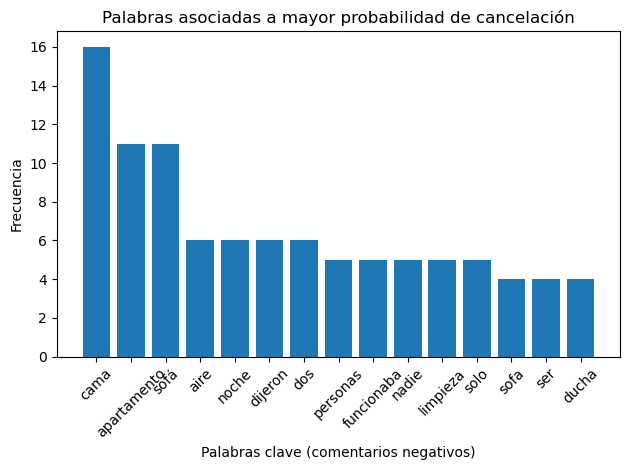

In [40]:
import matplotlib.pyplot as plt

df_cancel_words = pd.DataFrame(top_cancel, columns=["Palabra", "Frecuencia"])

plt.figure()
plt.bar(df_cancel_words["Palabra"], df_cancel_words["Frecuencia"])
plt.xticks(rotation=45)
plt.title("Palabras asociadas a mayor probabilidad de cancelación")
plt.xlabel("Palabras clave (comentarios negativos)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

clientes satisfechos vs riesgo de cancelación

In [39]:
# Opiniones con puntuación alta (clientes satisfechos)
df_ok = df_vitoria[df_vitoria['score'] >= 8]

texto_ok = " ".join(df_ok['positive_clean'])
palabras_ok = Counter(texto_ok.split()).most_common(15)

palabras_ok

[('ubicación', 189),
 ('apartamento', 116),
 ('bien', 102),
 ('limpio', 97),
 ('limpieza', 64),
 ('cómodo', 56),
 ('centro', 52),
 ('nuevo', 48),
 ('buena', 47),
 ('cerca', 42),
 ('cocina', 36),
 ('cama', 33),
 ('habitación', 33),
 ('equipado', 32),
 ('necesario', 31)]

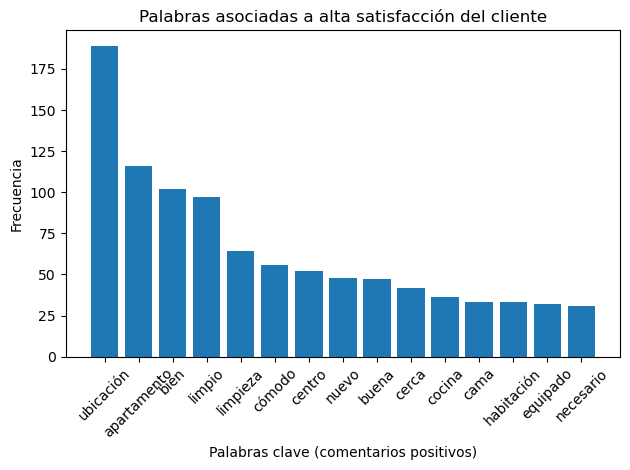

In [41]:
df_ok_words = pd.DataFrame(palabras_ok, columns=["Palabra", "Frecuencia"])

plt.figure()
plt.bar(df_ok_words["Palabra"], df_ok_words["Frecuencia"])
plt.xticks(rotation=45)
plt.title("Palabras asociadas a alta satisfacción del cliente")
plt.xlabel("Palabras clave (comentarios positivos)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

Limpiar los tags del scraping

In [71]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

def convertir_tags_seguro(tags):
    """
    Convierte cualquier formato de tags en una lista limpia de strings en minúsculas.
    """
    if pd.isna(tags):
        return []
    
    # Asegurar que es string
    tags = str(tags)
    
    # Separar por símbolo •
    partes = re.split(r'•', tags)
    
    # Limpiar y eliminar vacíos
    partes = [p.strip().lower() for p in partes if p.strip() != ""]
    
    return partes

df_vitoria['tags_clean'] = df_vitoria['tags'].apply(convertir_tags_seguro)

Extraer columnas desde tags_clean

In [72]:
def clasificar_tags(tags):
    return {
        "tipo_viaje": next((t for t in tags if "ocio" in t or "negocio" in t), None),
        "tipo_grupo": next((t for t in tags if "familia" in t or "pareja" in t), None),
        "tipo_habitacion": next((t for t in tags if "apartamento" in t or "habitación" in t), None),
        "duracion": next((t for t in tags if "noche" in t), None),
        "dispositivo": next((t for t in tags if "móvil" in t or "movil" in t), None),
    }

tags_df = df_vitoria['tags_clean'].apply(clasificar_tags).apply(pd.Series)
df_vitoria = pd.concat([df_vitoria, tags_df], axis=1)

Crear variable de riesgo de cancelación

In [76]:
df_vitoria['riesgo_cancelacion'] = df_vitoria['score'] <= 5

In [78]:
# Crear negative_clean (limpia y en minúsculas)
df_vitoria['negative_clean'] = df_vitoria['negative'].fillna("").str.lower()

Palabras más frecuentes en comentarios negativos (riesgo de cancelación)

In [82]:
from collections import Counter

# Lista básica de stopwords en español
stopwords_es = set([
    "que","no","el","la","los","las","y","a","en","un","una","para",
    "se","con","del","al","por","es","su","como","le","lo","me","te",
    "si","más","ya","o","pero","este","esta","eso","son","mi","nos","muy", "hay","de",
    ",","cuando", "era", "ni", "habia", "estaba", "sin", "desde", "había", "hasta", "ser", "q"
])

# Filtrar comentarios negativos de clientes con riesgo de cancelación
df_cancel = df_vitoria[df_vitoria['riesgo_cancelacion']]

texto_cancel = " ".join(df_cancel['negative_clean'].dropna()).lower()
palabras = [p for p in texto_cancel.split() if p not in stopwords_es]

# Contar palabras más frecuentes
palabras_cancel = Counter(palabras)
top_cancel = palabras_cancel.most_common(20)

# Convertir a DataFrame
df_cancel_words = pd.DataFrame(top_cancel, columns=["Palabra", "Frecuencia"])
print(df_cancel_words)


        Palabra  Frecuencia
0          cama          16
1          sofá          11
2   apartamento           8
3       dijeron           6
4           dos           6
5      personas           5
6             2           5
7    funcionaba           5
8          aire           5
9         nadie           5
10     limpieza           5
11         solo           5
12            4           4
13          día           4
14          mal           4
15        noche           4
16        check           4
17        abrir           4
18   habitación           3
19       además           3


Probabilidad de cancelación según tipo de grupo

In [83]:
# Eliminar registros sin tipo_grupo
df_grupo_limpio = df_vitoria[df_vitoria['tipo_grupo'].notna()]

prob_cancel_grupo = (
    df_grupo_limpio
    .groupby('tipo_grupo')['riesgo_cancelacion']
    .mean()
    .sort_values(ascending=False)
)
print(prob_cancel_grupo)

tipo_grupo
familia con niños pequeños', '    0.040419
pareja', '                        0.028571
Name: riesgo_cancelacion, dtype: float64


 Gráfico: riesgo de cancelación por tipo de grupo

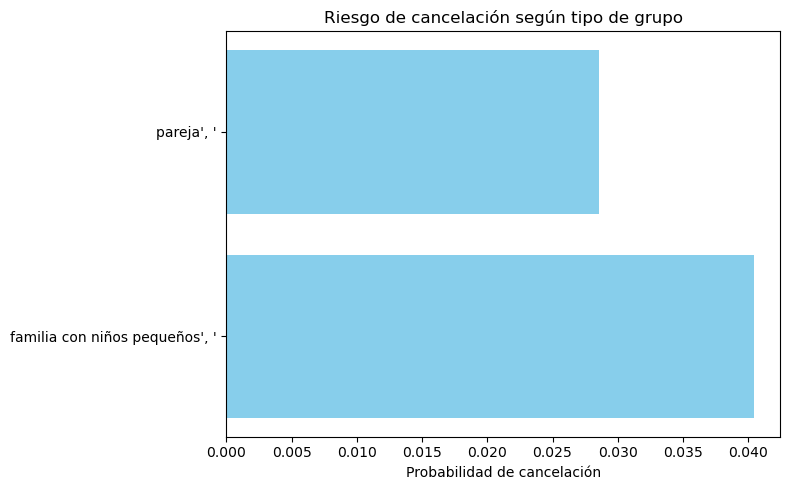

In [85]:
plt.figure(figsize=(8,5))
plt.barh(prob_cancel_grupo.index, prob_cancel_grupo.values, color='skyblue')
plt.xlabel("Probabilidad de cancelación")
plt.title("Riesgo de cancelación según tipo de grupo")
plt.tight_layout()
plt.show()

Probabilidad de cancelación por tipo de viaje

In [86]:
df_viaje_limpio = df_vitoria[df_vitoria['tipo_viaje'].notna()]

prob_cancel_viaje = (
    df_viaje_limpio
    .groupby('tipo_viaje')['riesgo_cancelacion']
    .mean()
    .sort_values(ascending=False)
)
print(prob_cancel_viaje)

tipo_viaje
viaje de negocios', '    0.064103
viaje de ocio', '        0.036442
Name: riesgo_cancelacion, dtype: float64


Gráfico: riesgo de cancelación por tipo de viaje

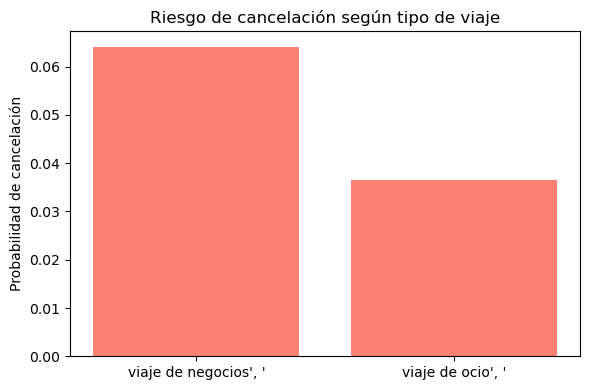

In [87]:
plt.figure(figsize=(6,4))
plt.bar(prob_cancel_viaje.index, prob_cancel_viaje.values, color='salmon')
plt.ylabel("Probabilidad de cancelación")
plt.title("Riesgo de cancelación según tipo de viaje")
plt.tight_layout()
plt.show()


## ANÁLISIS DE DONOSTI